# Load packages

In [1]:
from sklearn.neighbors import BallTree
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu

# Load data

In [2]:
data = pd.read_csv('/Users/wenqchen/Desktop/Projects/Auria/Data/t-CycIF/Data_AllMarkers_filtered_RCNs.csv', index_col=0)

/var/folders/rq/68pl8_s15_lc84mft22mqf012ws2td/T/ipykernel_28351/1161626377.py:1: DtypeWarning: Columns (33) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/Users/wenqchen/Desktop/Projects/Auria/Data/t-CycIF/Data_AllMarkers_filtered_RCNs.csv', index_col=0)


In [3]:
data

,S9.6,HER3,panCK,SMA,CD45,Ki67_2,CD4,FOXP3,CD8a,CD11b,...,antioxidant_TXNRD1,antioxidant_GLUT1,NQO1_GCLC_VIM,celltype_2,celltype_1,Tumor_state,GCLC_VIM,CellCategory,SC45px_neigh_kmeans_10,RCNs
CellID,,,,,,,,,,,,,,,,,,,,,
1,0.587351,0.668424,0.197573,0.119095,0.357855,0.221494,0.351031,0.261670,0.120537,0.641891,...,failed_classify,failed_classify,---,Other,Other.Stroma,Other.Stroma,Other.Stroma,Stroma,4,RCN3
10,0.711467,0.738836,0.522747,0.185507,0.275963,0.214838,0.374685,0.350623,0.029450,0.608733,...,TXNRD1_pos,failed_classify,+--,Tumor_+--,Tumor,Tumor,Tumor.GCLC-VIM-,Tumor,2,RCN1
10,0.803970,0.824031,0.331924,0.204348,0.355699,0.234078,0.518679,0.390894,0.161177,0.666724,...,failed_classify,failed_classify,+--,CD68.Macrophages,CD68.Macrophages,CD68.Macrophages,CD68.Macrophages,Immune,4,RCN3
100,0.744246,0.762114,0.531392,0.185345,0.246533,0.227313,0.392369,0.348677,0.023832,0.619029,...,TXNRD1_pos,failed_classify,+--,Tumor_+--,Tumor,Tumor,Tumor.GCLC-VIM-,Tumor,2,RCN1
100,0.796639,0.796858,0.357244,0.192493,0.431782,0.228827,0.489430,0.380457,0.156145,0.674359,...,failed_classify,failed_classify,---,Immune,Other.Immune,Other.Immune,Other.Immune,Immune,4,RCN3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99998,0.832069,0.723583,0.638020,0.130660,0.135379,0.173406,0.316902,0.220026,0.366662,0.634752,...,failed_classify,failed_classify,---,Tumor_---,Tumor,Tumor,Tumor.GCLC-VIM-,Tumor,2,RCN1
99999,0.770561,0.929819,0.451729,0.390374,0.620998,0.488494,0.532568,0.522331,0.467017,0.871813,...,failed_classify,failed_classify,-++,FOXP3.CD4.Tregs,Treg,Treg,Treg,Immune,1,RCN2
99999,0.678946,0.721054,0.228812,0.598502,0.598347,0.229858,0.528080,0.499220,0.232839,0.704152,...,failed_classify,failed_classify,-++,CD4.T.cells,CD4.T.cells,CD4.T.cells,CD4.T.cells,Immune,1,RCN2


In [4]:
data['CellCategory'].value_counts()

CellCategory
Tumor     1773160
Immune    1123431
Stroma     785181
Name: count, dtype: int64

# Function

## Immune proportions in RCNs

In [130]:
def compute_rcn_immune_proportions_multiimage(df,
                                               center_cell_types,
                                               immune_cell_types,
                                               radius=45,
                                               x_col='X_centroid', y_col='Y_centroid',
                                               celltype_col='GCLC_VIM',
                                               rcn_col='RCNs',
                                               image_col='imageid'):
    """
    Compute immune cell proportions around each center cell within specified radius.
    Returns two DataFrames:
    1. result_df: Aggregated proportions by (CenterType, RCN, ImmuneCellType)
    2. cell_df: Detailed results for each center cell with immune cell counts and proportions
    """
    all_local_results = []
    all_cell_results = []

    for image_id, df_img in df.groupby(image_col):
        print(f'Processing image: {image_id} ({len(df_img)} cells)')

        coords = df_img[[x_col, y_col]].values
        tree = BallTree(coords, metric='euclidean')

        for center_type in center_cell_types:
            centers = df_img[df_img[celltype_col] == center_type]
            print(f'  CenterType {center_type} - {len(centers)} cells')

            for idx, row in centers.iterrows():
                center_point = [[row[x_col], row[y_col]]]
                indices = tree.query_radius(center_point, r=radius)[0]
                neighbors = df_img.iloc[indices]
                
                # Calculate total cells in radius (including center cell)
                total_neighbors = len(neighbors)
                
                # Get immune neighbors
                immune_neighbors = neighbors[neighbors[celltype_col].isin(immune_cell_types)]
                total_immune = len(immune_neighbors)
                
                # Initialize cell-level result dictionary
                cell_result = {
                    'CellID': idx,
                    'CenterType': center_type,
                    'ImageID': image_id,
                    'RCN': row[rcn_col],
                    'TotalNeighbors': total_neighbors,
                    'TotalImmuneNeighbors': total_immune
                }
                
                # Calculate counts and proportions for each immune cell type
                immune_counts = immune_neighbors[celltype_col].value_counts()
                
                for imm_type in immune_cell_types:
                    count = immune_counts.get(imm_type, 0)
                    prop = count / total_immune if total_immune > 0 else 0
                    
                    # Add to cell result
                    cell_result[f'{imm_type}_Count'] = count
                    cell_result[f'{imm_type}_Proportion'] = prop
                    
                    # Add to aggregate results
                    if count > 0:
                        all_local_results.append({
                            'CenterType': center_type,
                            'RCN': row[rcn_col],
                            'ImmuneCellType': imm_type,
                            'Proportion': prop
                        })
                
                all_cell_results.append(cell_result)

    # Create cell_df
    cell_df = pd.DataFrame(all_cell_results)
    
    # Aggregate results across images
    if all_local_results:
        local_df = pd.DataFrame(all_local_results)
        result_df = local_df.groupby(['CenterType', 'RCN', 'ImmuneCellType'])['Proportion'].mean().reset_index()
        result_df = result_df.rename(columns={'Proportion': 'MeanProportion'})
    else:
        result_df = pd.DataFrame(columns=['CenterType', 'RCN', 'ImmuneCellType', 'MeanProportion'])

    return result_df, cell_df


## Stacked barplot

In [34]:
def plot_immune_proportions_by_rcn(result_df, center_cell_types, colors_dict, 
                                   figsize=(16, 12), style='seaborn-v0_8-whitegrid',
                                   title='Immune Cell Proportions by RCN for Different Tumor Types',
                                   legend_first_only=True):
    """
    Plot stacked bar charts of immune cell proportions by RCN for different tumor center types.
    
    Parameters:
    -----------
    result_df : pandas DataFrame
        DataFrame containing immune cell proportions data with columns:
        'CenterType', 'RCN', 'ImmuneCellType', 'NormalizedProportion'
    center_cell_types : list
        List of center cell types to plot
    colors_dict : dict
        Dictionary mapping immune cell types to colors
    figsize : tuple, optional
        Figure size (width, height) in inches
    style : str, optional
        Matplotlib style to use
    title : str, optional
        Main title for the figure
    legend_first_only : bool, optional
        If True, only show legend on the first subplot
    """
    # Set figure style
    plt.style.use(style)
    
    # Create subplots - adjust rows and columns based on number of center types
    n = len(center_cell_types)
    rows = int(np.ceil(n / 2))
    cols = min(2, n)
    
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    if n == 1:
        axes = [axes]  # Convert to list if there's only one subplot
    else:
        axes = axes.flatten()
    
    # Loop through the center types
    for i, center_type in enumerate(center_cell_types):
        if i >= len(axes):
            break
            
        # Filter data for this center type
        center_data = result_df[result_df['CenterType'] == center_type]
        
        # Pivot to get the right format for stacked barplot
        pivot_data = center_data.pivot(index='RCN', columns='ImmuneCellType', values='NormalizedProportion').fillna(0)
        
        # Sort by RCN numerical value
        rcn_order = sorted(pivot_data.index, key=lambda x: int(x.replace('RCN', '')))
        pivot_data = pivot_data.reindex(rcn_order)
        
        # Plot
        pivot_data.plot(kind='bar', stacked=True, ax=axes[i], color=colors_dict, width=0.7)
        
        # Customize plot
        axes[i].set_title(f"{center_type}", fontsize=14)
        axes[i].set_xlabel("RCN", fontsize=12)
        axes[i].set_ylabel("Normalized Proportion", fontsize=12)
        axes[i].tick_params(axis='both', labelsize=11)
        axes[i].grid(axis='y', linestyle='--', alpha=0.7)
        
        if i == 0 or not legend_first_only:
            axes[i].legend(title='Immune Cell Type', bbox_to_anchor=(1.05, 1), loc='upper left')
        else:
            axes[i].legend().set_visible(False)
    
    # Hide unused subplots
    for i in range(len(center_cell_types), len(axes)):
        axes[i].axis('off')
    
    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    
    if title:
        fig.suptitle(title, fontsize=16)
    
    plt.show()
    return fig, axes

## Compare_tumor_neighborhoods

In [8]:
def compare_tumor_neighborhoods(
    df,
    group_col,
    group1_label,
    group2_label,
    marker_cols,
    marker_labels=None,
    radius_px=45,
    figsize=(5, 5),
    auto_ylim=True,
    y_padding=0.1
):
    """
    Draw comparative boxplots showing the proportions of immune cell types in the neighborhoods of two tumor cell categories.

    Parameters:
    - df: DataFrame, containing tumor type column and immune cell proportion columns
    - group_col: str, classification column name to compare, e.g. "GCLC_VIM"
    - group1_label, group2_label: str, the two categories to compare
    - marker_cols: list of str, column names representing immune cell proportions
    - marker_labels: list of str, display labels corresponding to marker_cols (optional)
    - radius_px: int, neighborhood radius in pixels (for plot title)
    - figsize: tuple, size of each plot
    - auto_ylim: bool, automatically adjust y-axis range to better show data differences
    - y_padding: float, padding ratio to add to y-axis when auto_ylim=True
    """

    # Filter data
    sub_df = df[df[group_col].isin([group1_label, group2_label])].copy()
    sub_df[group_col] = sub_df[group_col].astype(str)  # Prevent category type issues

    # Set labels
    if marker_labels is None:
        marker_labels = marker_cols

    # Draw plots for each marker with significance annotation
    for marker, label in zip(marker_cols, marker_labels):
        plt.figure(figsize=figsize)
        # Use boxplot as requested
        sns.boxplot(data=sub_df, x=group_col, y=marker, showfliers=False)
        sns.stripplot(data=sub_df,
            x=group_col,
            y=marker,
            color='black',
            alpha=0.3,
            jitter=0.25,
            size=2.5,
            zorder=1)

        # Statistical test
        data1 = sub_df[sub_df[group_col] == group1_label][marker]
        data2 = sub_df[sub_df[group_col] == group2_label][marker]
        stat, pval = mannwhitneyu(data1, data2, alternative='two-sided')

        # Automatically adjust y-axis range to better show data differences
        if auto_ylim:
            min_val = sub_df[marker].min()
            max_val = sub_df[marker].max()
            y_range = max_val - min_val
            # Add padding to ensure points aren't clipped
            y_min = max(0, min_val - y_range * y_padding)  # Not less than 0
            y_max = max_val + y_range * y_padding
            plt.ylim(y_min, y_max)

        # Significance annotation
        p_label = f"p = {pval:.3f}" if pval >= 0.001 else "p < 0.001"
        
        # Adjust p-value label position
        if auto_ylim:
            y_pos = max_val + y_range * y_padding * 0.7
        else:
            y_pos = sub_df[marker].max() * 0.9
        
        plt.text(0.5, y_pos, p_label, ha='center')
        plt.ylabel(f"{label} Proportion")
        plt.title(f"{label} in {radius_px}px Radius")
        plt.tight_layout()
        plt.show()

# Run

In [131]:
center_cell_types=['Tumor.GCLC+VIM+', 'Tumor.GCLC+VIM-', 'Tumor.GCLC-VIM+', 'Tumor.GCLC-VIM-']
immune_cell_types=['CD206.Macrophages', 'CD68.Macrophages', 'CD4.T.cells', 'CD8.T.cells', 'Treg', 'Other.Immune']

In [132]:
result_df, cell_df = compute_rcn_immune_proportions_multiimage(df=data,
                                                      center_cell_types = center_cell_types,
                                                      immune_cell_types = immune_cell_types,
                                                      radius=45,
                                                      x_col='X_centroid', y_col='Y_centroid',
                                                      celltype_col='GCLC_VIM',
                                                      rcn_col='RCNs',
                                                      image_col='imageid')

Processing image: 19_02_01A (439748 cells)
  CenterType Tumor.GCLC+VIM+ - 19957 cells
  CenterType Tumor.GCLC+VIM- - 9443 cells
  CenterType Tumor.GCLC-VIM+ - 2813 cells
  CenterType Tumor.GCLC-VIM- - 206512 cells
Processing image: 19_02_02A (407940 cells)
  CenterType Tumor.GCLC+VIM+ - 52999 cells
  CenterType Tumor.GCLC+VIM- - 11606 cells
  CenterType Tumor.GCLC-VIM+ - 6118 cells
  CenterType Tumor.GCLC-VIM- - 90437 cells
Processing image: 19_02_03A (512122 cells)
  CenterType Tumor.GCLC+VIM+ - 11866 cells
  CenterType Tumor.GCLC+VIM- - 66000 cells
  CenterType Tumor.GCLC-VIM+ - 170 cells
  CenterType Tumor.GCLC-VIM- - 265141 cells
Processing image: 1B (490802 cells)
  CenterType Tumor.GCLC+VIM+ - 42916 cells
  CenterType Tumor.GCLC+VIM- - 928 cells
  CenterType Tumor.GCLC-VIM+ - 58162 cells
  CenterType Tumor.GCLC-VIM- - 136948 cells
Processing image: 2B (445742 cells)
  CenterType Tumor.GCLC+VIM+ - 16398 cells
  CenterType Tumor.GCLC+VIM- - 806 cells
  CenterType Tumor.GCLC-VIM+ - 

In [61]:
cell_df

,CellID,CenterType,ImageID,RCN,TotalNeighbors,TotalImmuneNeighbors,CD206.Macrophages_Count,CD206.Macrophages_Proportion,CD68.Macrophages_Count,CD68.Macrophages_Proportion,CD4.T.cells_Count,CD4.T.cells_Proportion,CD8.T.cells_Count,CD8.T.cells_Proportion,Treg_Count,Treg_Proportion,Other.Immune_Count,Other.Immune_Proportion
0,10255,Tumor.GCLC+VIM+,19_02_01A,RCN1,19,4,0,0.0,1,0.25,0,0.00,0,0.0,1,0.25,2,0.50
1,10270,Tumor.GCLC+VIM+,19_02_01A,RCN6,2,1,0,0.0,0,0.00,0,0.00,0,0.0,1,1.00,0,0.00
2,105168,Tumor.GCLC+VIM+,19_02_01A,RCN1,8,0,0,0.0,0,0.00,0,0.00,0,0.0,0,0.00,0,0.00
3,105174,Tumor.GCLC+VIM+,19_02_01A,RCN1,8,0,0,0.0,0,0.00,0,0.00,0,0.0,0,0.00,0,0.00
4,105175,Tumor.GCLC+VIM+,19_02_01A,RCN1,7,0,0,0.0,0,0.00,0,0.00,0,0.0,0,0.00,0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1773155,9986,Tumor.GCLC-VIM-,T2,RCN2,17,2,0,0.0,0,0.00,1,0.50,1,0.5,0,0.00,0,0.00
1773156,9987,Tumor.GCLC-VIM-,T2,RCN1,18,2,0,0.0,0,0.00,0,0.00,1,0.5,0,0.00,1,0.50
1773157,9990,Tumor.GCLC-VIM-,T2,RCN3,15,2,0,0.0,0,0.00,1,0.50,0,0.0,1,0.50,0,0.00
1773158,9997,Tumor.GCLC-VIM-,T2,RCN2,23,4,0,0.0,0,0.00,1,0.25,0,0.0,0,0.00,3,0.75


In [64]:
result_df

,CenterType,RCN,ImmuneCellType,MeanProportion,NormalizedProportion
0,Tumor.GCLC+VIM+,RCN1,CD206.Macrophages,0.699731,0.170177
1,Tumor.GCLC+VIM+,RCN1,CD4.T.cells,0.640644,0.155807
2,Tumor.GCLC+VIM+,RCN1,CD68.Macrophages,0.846041,0.205760
3,Tumor.GCLC+VIM+,RCN1,CD8.T.cells,0.648038,0.157605
4,Tumor.GCLC+VIM+,RCN1,Other.Immune,0.639011,0.155410
...,...,...,...,...,...
235,Tumor.GCLC-VIM-,RCN9,CD4.T.cells,0.133863,0.089729
236,Tumor.GCLC-VIM-,RCN9,CD68.Macrophages,0.757420,0.507704
237,Tumor.GCLC-VIM-,RCN9,CD8.T.cells,0.194575,0.130425
238,Tumor.GCLC-VIM-,RCN9,Other.Immune,0.157276,0.105423


In [63]:
result_df['NormalizedProportion'] = result_df.groupby(['CenterType', 'RCN'])['MeanProportion'].transform(lambda x: x / x.sum())

In [67]:
result_df.to_csv('/Users/wenqchen/Desktop/Projects/Auria/Data/t-CycIF/RCN_immune_proportions_multiimage.csv')

In [68]:
cell_df.to_csv('/Users/wenqchen/Desktop/Projects/Auria/Data/t-CycIF/RCN_immune_proportions_multiimage_percell.csv')

In [65]:
colors_dict = {
    'CD206.Macrophages': '#A2C8DD', 
    'CD68.Macrophages': '#589AC4',
    'CD4.T.cells': '#A5CE4D',   
    'CD8.T.cells': '#E6756F',    
    'Treg': '#EFAB6D',   
    'Other.Immune': '#f4f1d0',    
}

## Stacked barplot

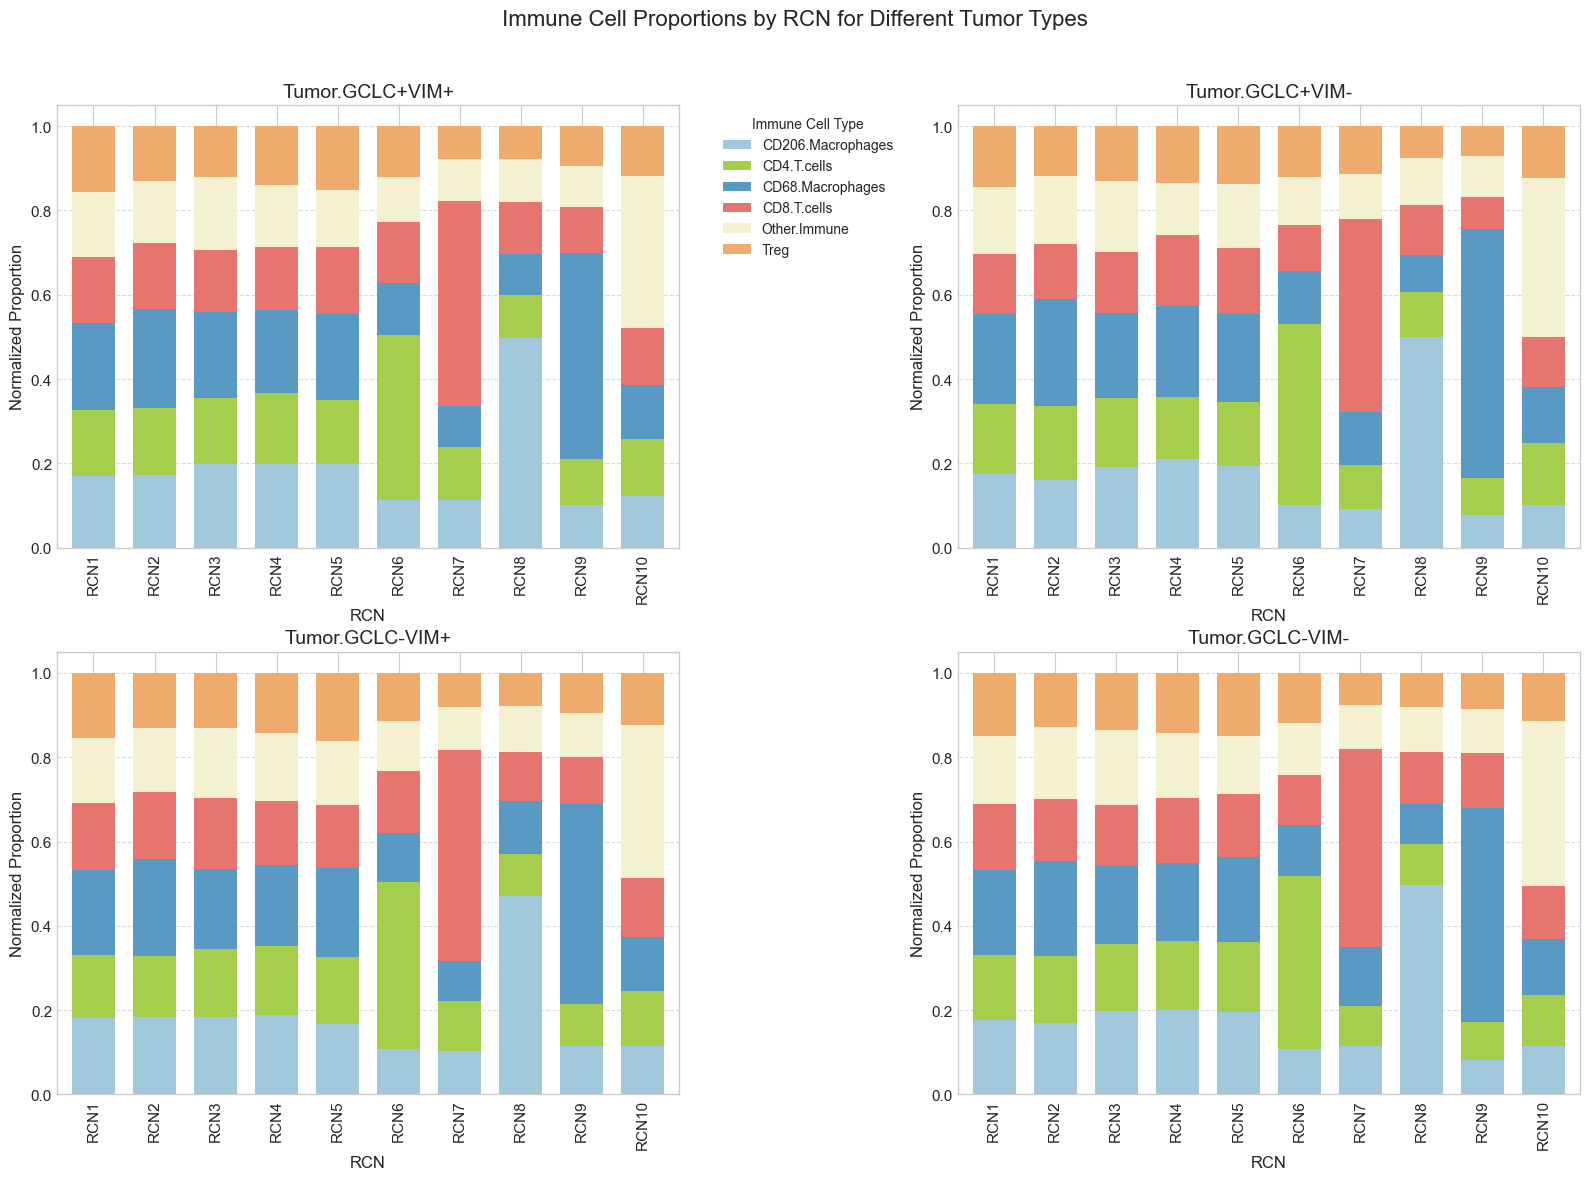

(<Figure size 1600x1200 with 4 Axes>,
 array([<Axes: title={'center': 'Tumor.GCLC+VIM+'}, xlabel='RCN', ylabel='Normalized Proportion'>,
        <Axes: title={'center': 'Tumor.GCLC+VIM-'}, xlabel='RCN', ylabel='Normalized Proportion'>,
        <Axes: title={'center': 'Tumor.GCLC-VIM+'}, xlabel='RCN', ylabel='Normalized Proportion'>,
        <Axes: title={'center': 'Tumor.GCLC-VIM-'}, xlabel='RCN', ylabel='Normalized Proportion'>],
       dtype=object))

In [66]:
plot_immune_proportions_by_rcn(result_df = result_df, 
                               center_cell_types = center_cell_types,
                               colors_dict = colors_dict,
                               figsize=(16, 12),
                               style='seaborn-v0_8-whitegrid',
                               title='Immune Cell Proportions by RCN for Different Tumor Types',
                               legend_first_only=True)

## Compare_tumor_neighborhoods

In [5]:
cell_df = pd.read_csv('/Users/wenqchen/Desktop/Projects/Auria/Data/t-CycIF/RCN_immune_proportions_multiimage_percell.csv', index_col=0)

In [6]:
cell_df

,CellID,CenterType,ImageID,RCN,TotalNeighbors,TotalImmuneNeighbors,CD206.Macrophages_Count,CD206.Macrophages_Proportion,CD68.Macrophages_Count,CD68.Macrophages_Proportion,CD4.T.cells_Count,CD4.T.cells_Proportion,CD8.T.cells_Count,CD8.T.cells_Proportion,Treg_Count,Treg_Proportion,Other.Immune_Count,Other.Immune_Proportion
0,10255,Tumor.GCLC+VIM+,19_02_01A,RCN1,19,4,0,0.0,1,0.25,0,0.00,0,0.0,1,0.25,2,0.50
1,10270,Tumor.GCLC+VIM+,19_02_01A,RCN6,2,1,0,0.0,0,0.00,0,0.00,0,0.0,1,1.00,0,0.00
2,105168,Tumor.GCLC+VIM+,19_02_01A,RCN1,8,0,0,0.0,0,0.00,0,0.00,0,0.0,0,0.00,0,0.00
3,105174,Tumor.GCLC+VIM+,19_02_01A,RCN1,8,0,0,0.0,0,0.00,0,0.00,0,0.0,0,0.00,0,0.00
4,105175,Tumor.GCLC+VIM+,19_02_01A,RCN1,7,0,0,0.0,0,0.00,0,0.00,0,0.0,0,0.00,0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1773155,9986,Tumor.GCLC-VIM-,T2,RCN2,17,2,0,0.0,0,0.00,1,0.50,1,0.5,0,0.00,0,0.00
1773156,9987,Tumor.GCLC-VIM-,T2,RCN1,18,2,0,0.0,0,0.00,0,0.00,1,0.5,0,0.00,1,0.50
1773157,9990,Tumor.GCLC-VIM-,T2,RCN3,15,2,0,0.0,0,0.00,1,0.50,0,0.0,1,0.50,0,0.00
1773158,9997,Tumor.GCLC-VIM-,T2,RCN2,23,4,0,0.0,0,0.00,1,0.25,0,0.0,0,0.00,3,0.75


In [ ]:
compare_tumor_neighborhoods(
    df = cell_df,
    group_col = "CenterType",
    group1_label = "Tumor.GCLC+VIM+",
    group2_label = "Tumor.GCLC+VIM-",
    marker_cols = ['CD206.Macrophages_Proportion', 'CD68.Macrophages_Proportion',
                   'CD4.T.cells_Proportion', 'CD8.T.cells_Proportion', 'Treg_Proportion', 'Other.Immune_Proportion'],
    marker_labels = ['CD206.Macrophages', 'CD68.Macrophages', 'CD4.T.cells', 'CD8.T.cells', 'Treg', 'Other.Immune'],
    radius_px = 45,
    figsize=(5, 5),
    auto_ylim=True,  # New parameter to toggle automatic y-limits
    y_padding=0.1
)


## Distribution

In [15]:
df = pd.DataFrame(cell_df['TotalNeighbors'].value_counts())
df.to_csv('/Users/wenqchen/Desktop/Projects/Auria/Data/t-CycIF/TotalNeighbors.csv')

In [16]:
df = pd.DataFrame(cell_df['TotalImmuneNeighbors'].value_counts())
df.to_csv('/Users/wenqchen/Desktop/Projects/Auria/Data/t-CycIF/TotalImmuneNeighbors.csv')

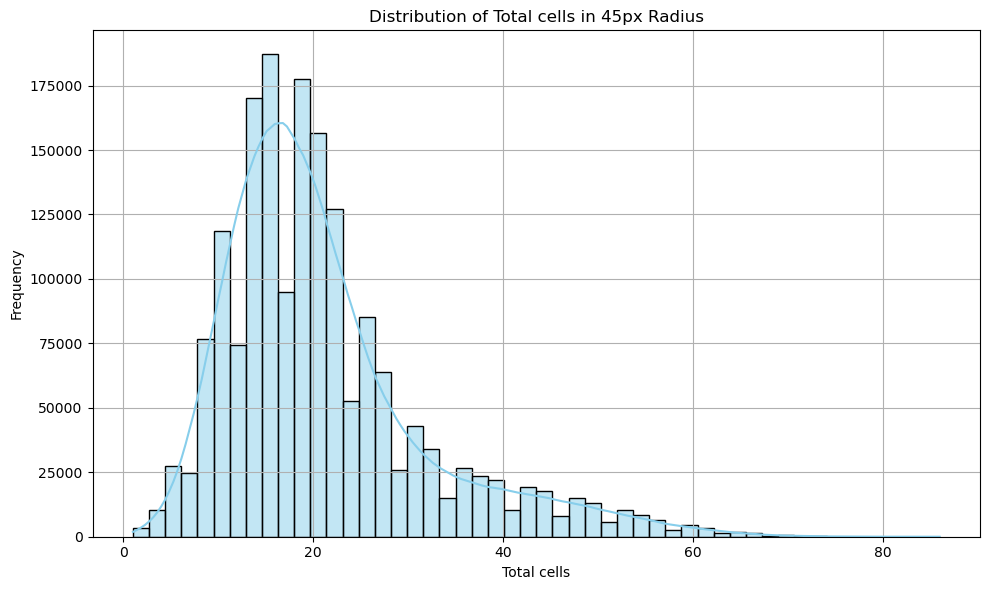

In [10]:
plt.figure(figsize=(10, 6))
sns.histplot(cell_df['TotalNeighbors'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Total cells in 45px Radius')
plt.xlabel('Total cells')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

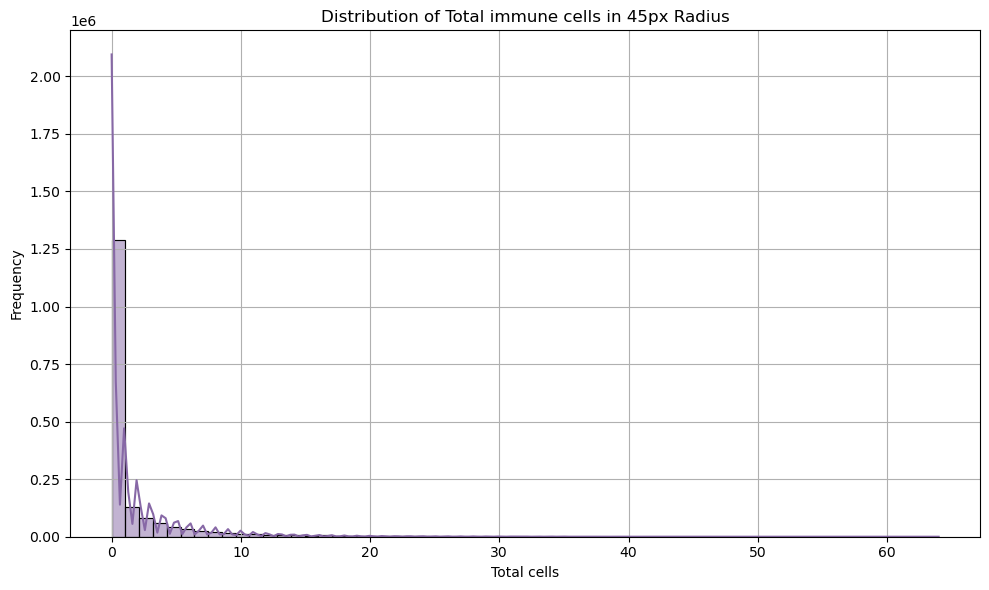

In [21]:
plt.figure(figsize=(10, 6))
sns.histplot(cell_df['TotalImmuneNeighbors'], bins=60, kde=True, color='#8768a6')
plt.title('Distribution of Total immune cells in 45px Radius')
plt.xlabel('Total cells')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

# Test

   CellID       CenterType    ImageID   RCN  TotalNeighbors  \
0   10255  Tumor.GCLC+VIM+  19_02_01A  RCN1              19   
1   10270  Tumor.GCLC+VIM+  19_02_01A  RCN6               2   
2  105168  Tumor.GCLC+VIM+  19_02_01A  RCN1               8   
3  105174  Tumor.GCLC+VIM+  19_02_01A  RCN1               8   
4  105175  Tumor.GCLC+VIM+  19_02_01A  RCN1               7   

   TotalImmuneNeighbors  CD206.Macrophages_Count  \
0                     4                        0   
1                     1                        0   
2                     0                        0   
3                     0                        0   
4                     0                        0   

   CD206.Macrophages_Proportion  CD68.Macrophages_Count  \
0                           0.0                       1   
1                           0.0                       0   
2                           0.0                       0   
3                           0.0                       0   
4            

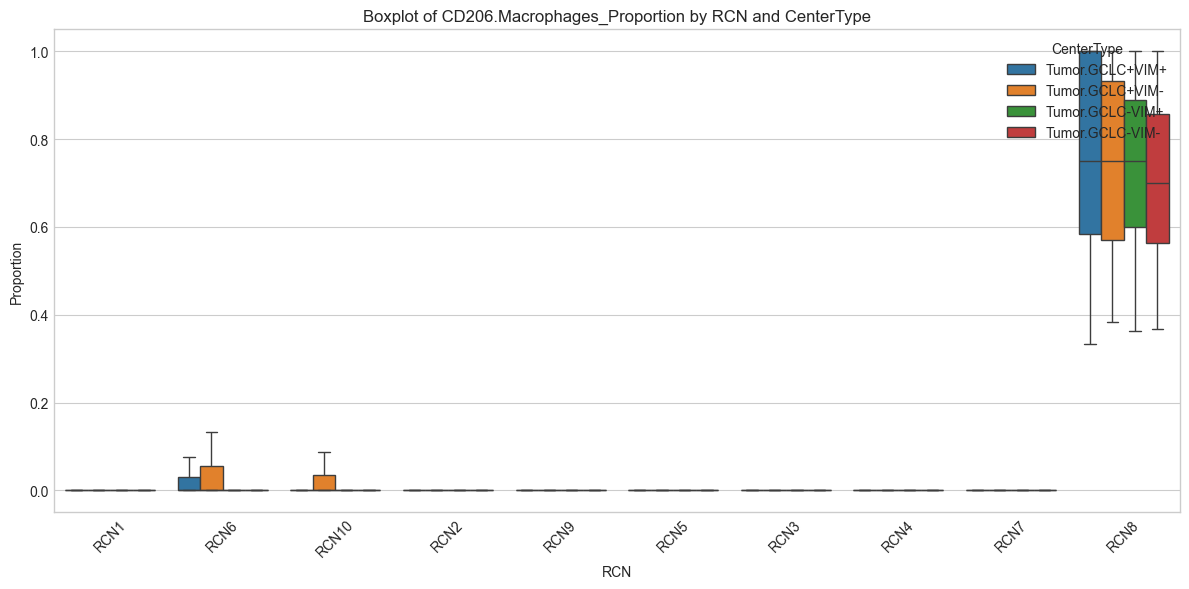

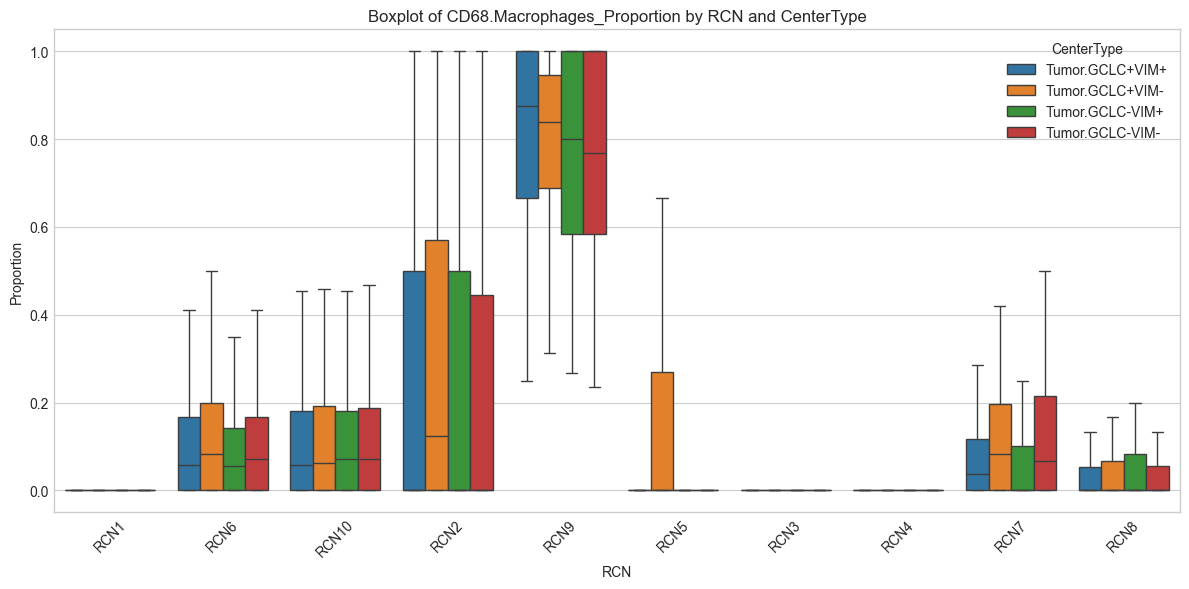

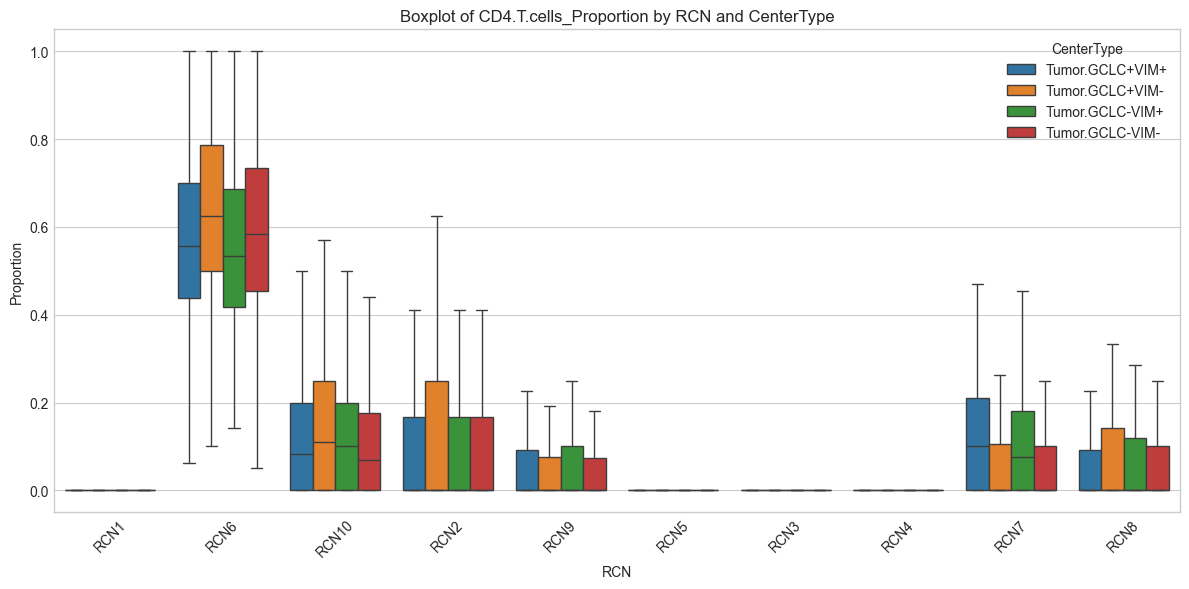

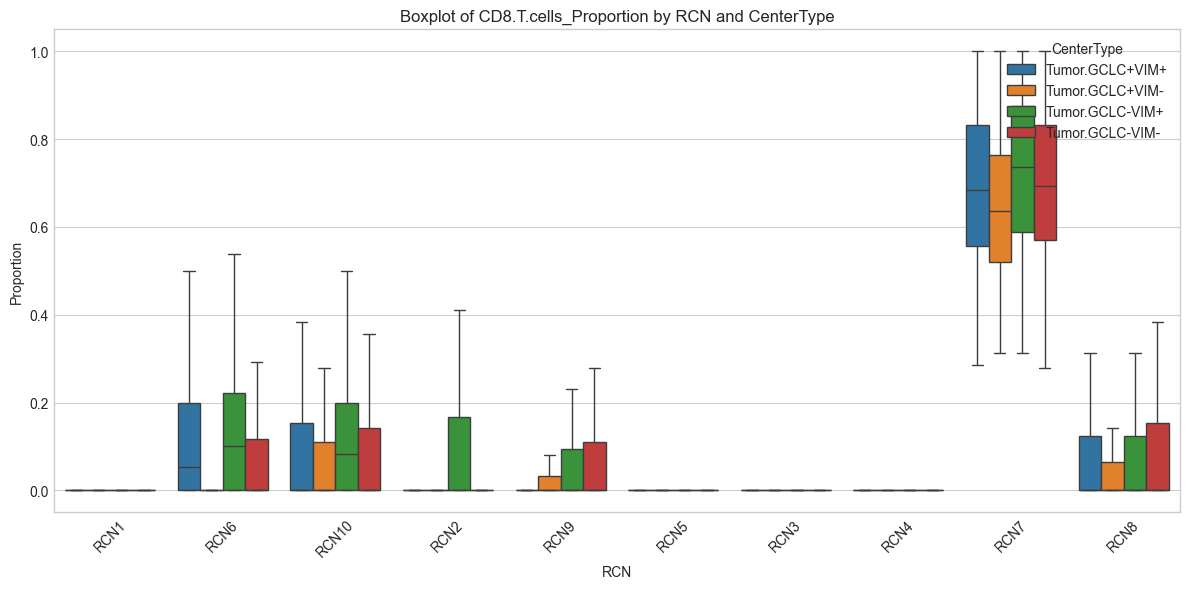

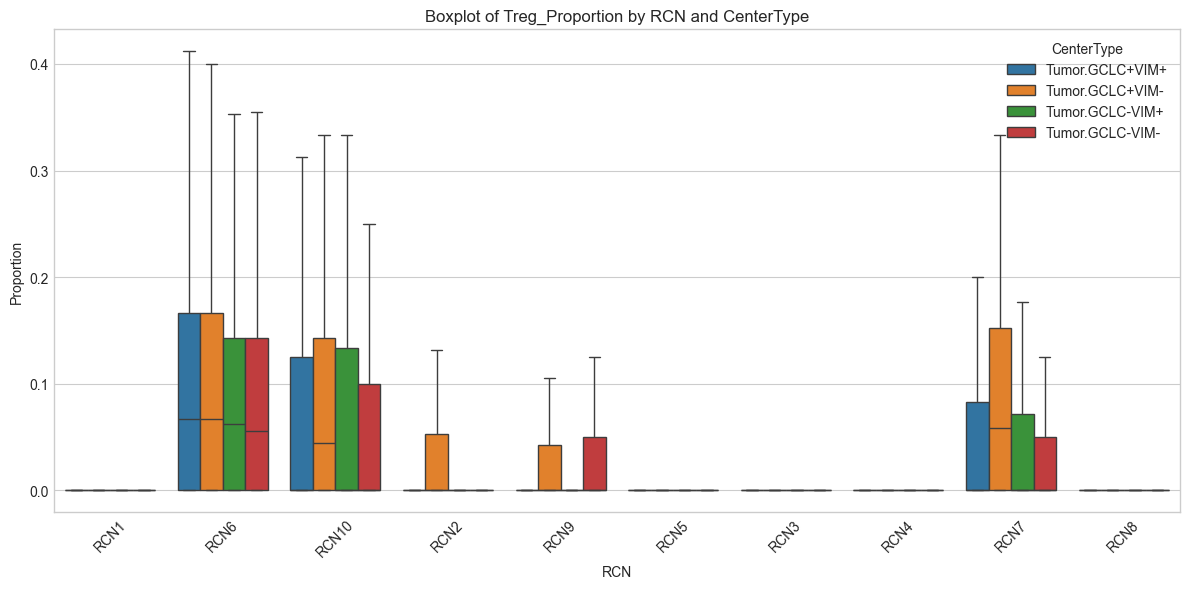

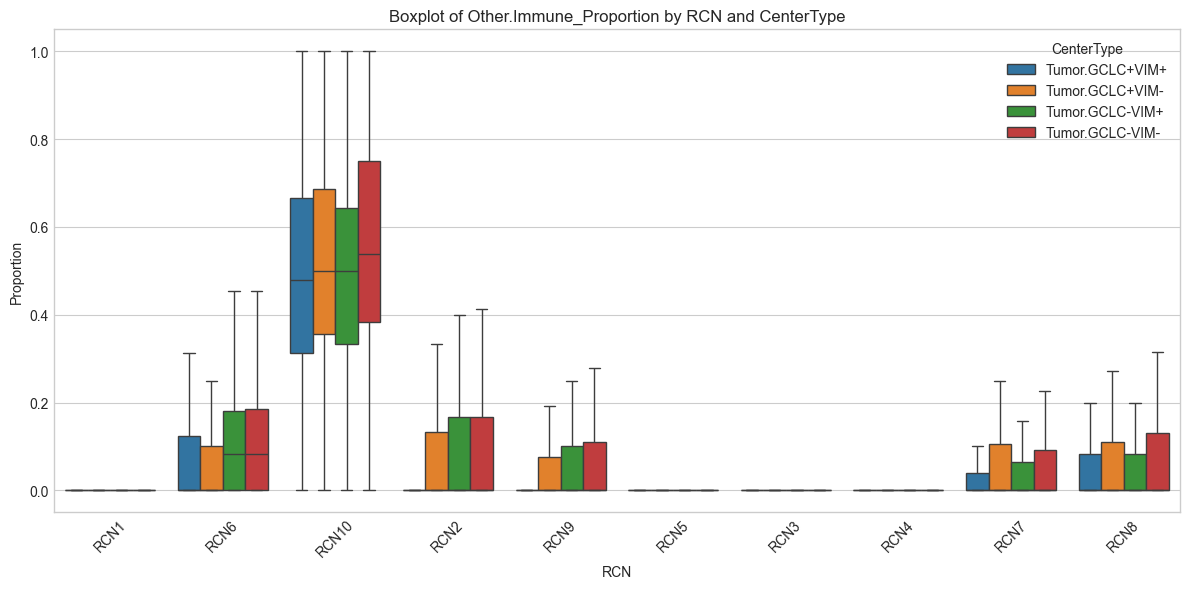

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 读取数据，假设数据保存在 "data.tsv" 文件中，分隔符为制表符
df = cell_df

# 检查数据加载情况（可选）
print(df.head())

# 定义要绘制比例的免疫细胞类型列
immune_proportion_cols = [
    "CD206.Macrophages_Proportion",
    "CD68.Macrophages_Proportion",
    "CD4.T.cells_Proportion",
    "CD8.T.cells_Proportion",
    "Treg_Proportion",
    "Other.Immune_Proportion"
]

# 循环绘制每个免疫细胞类型的 boxplot
for col in immune_proportion_cols:
    plt.figure(figsize=(12, 6))
    # 使用 RCN 作为横坐标，比例作为纵坐标，用 CenterType 划分颜色，对比肿瘤类型（Tumor.GCLC-VIM- vs Tumor.GCLC+VIM+）
    ax = sns.boxplot(data=df, x="RCN", y=col, hue="CenterType", showfliers=False)
    plt.title(f"{col}")
    plt.xlabel("RCN")
    plt.ylabel("Proportion")
    plt.xticks(rotation=45)
    plt.legend(title="CenterType", loc="upper right")
    plt.tight_layout()
    plt.show()


In [124]:
cell_df['RCN'].unique()

array(['RCN1', 'RCN6', 'RCN10', 'RCN2', 'RCN9', 'RCN5', 'RCN3', 'RCN4',
       'RCN7', 'RCN8'], dtype=object)

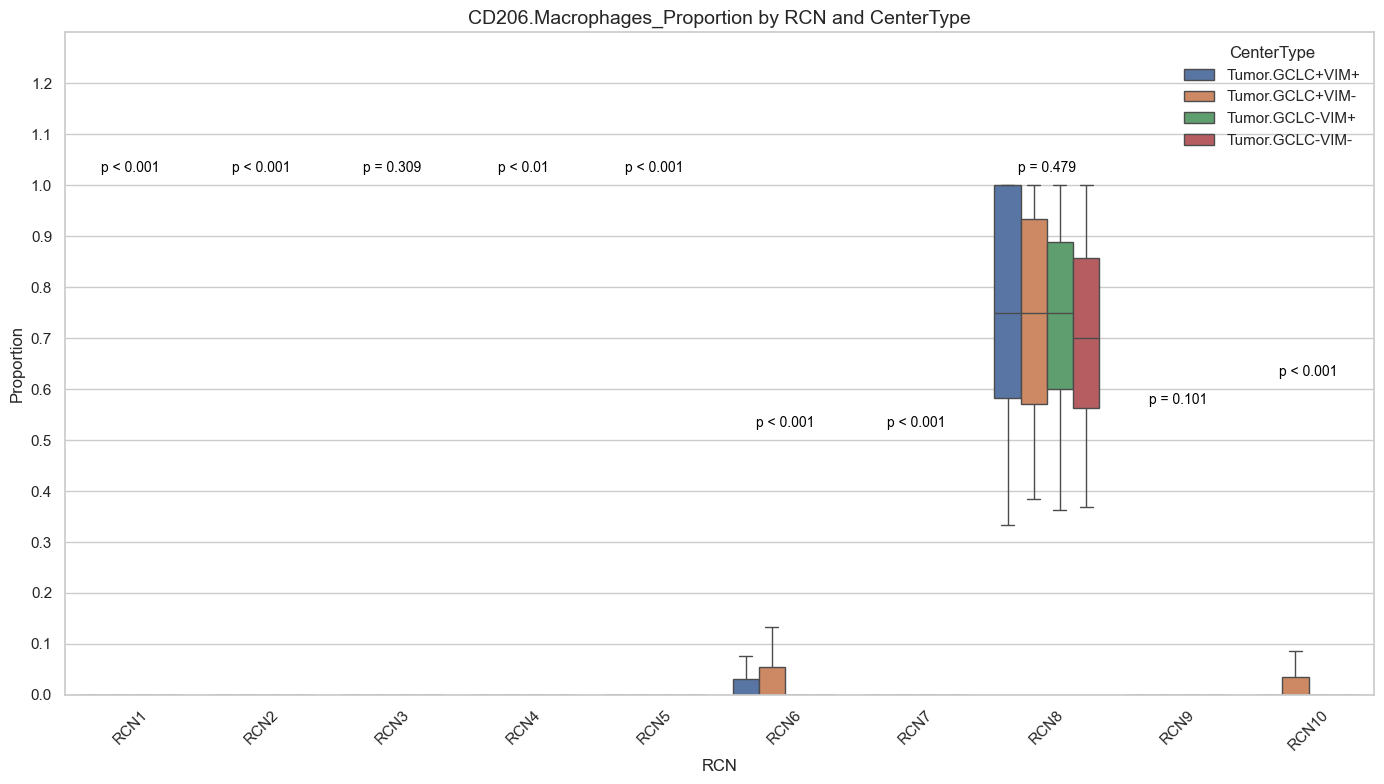

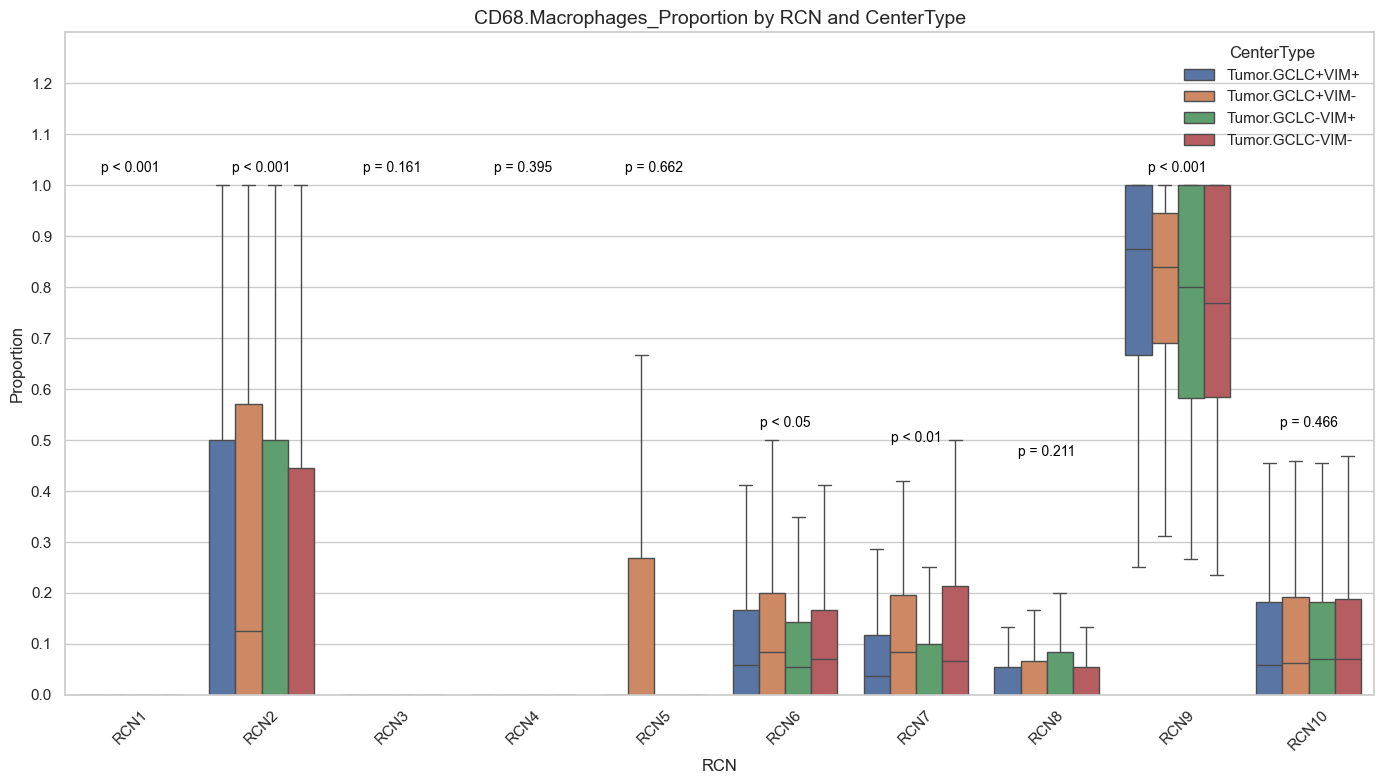

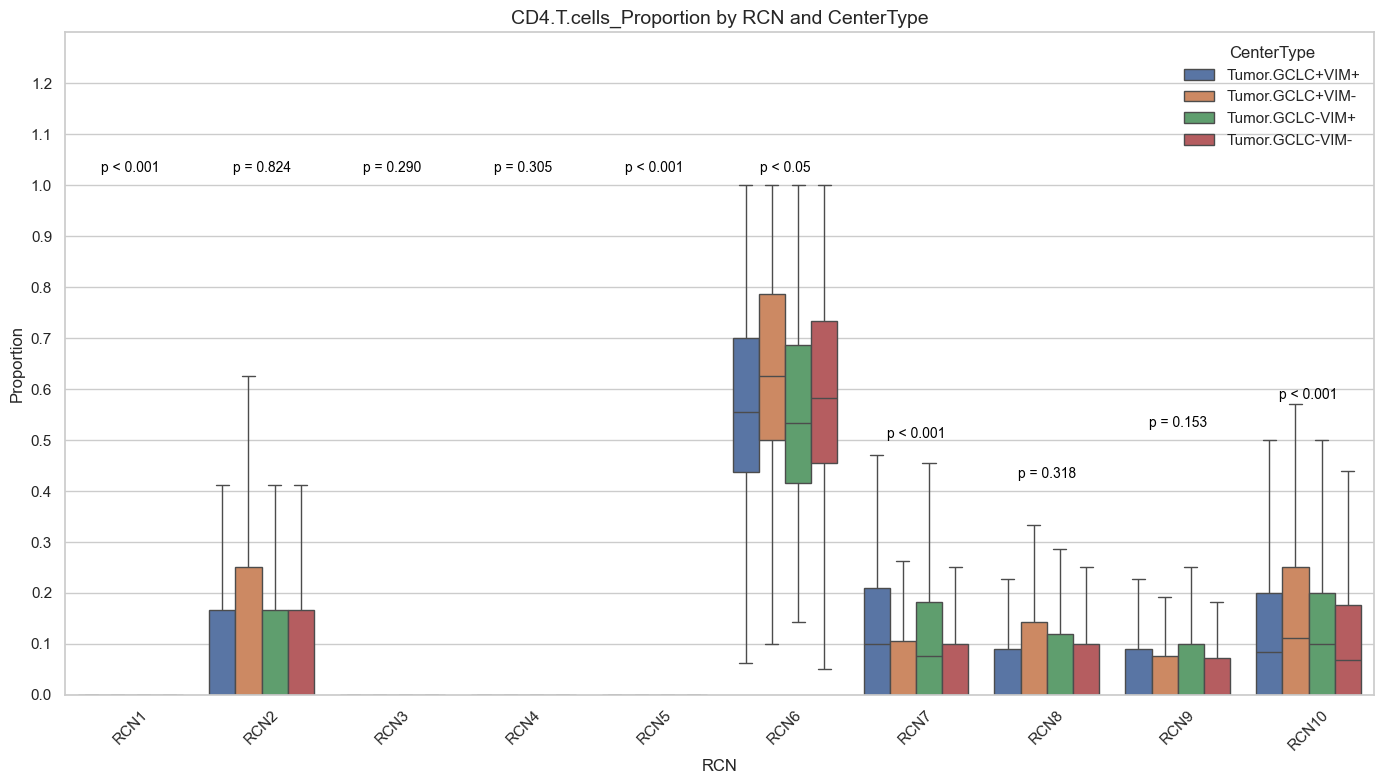

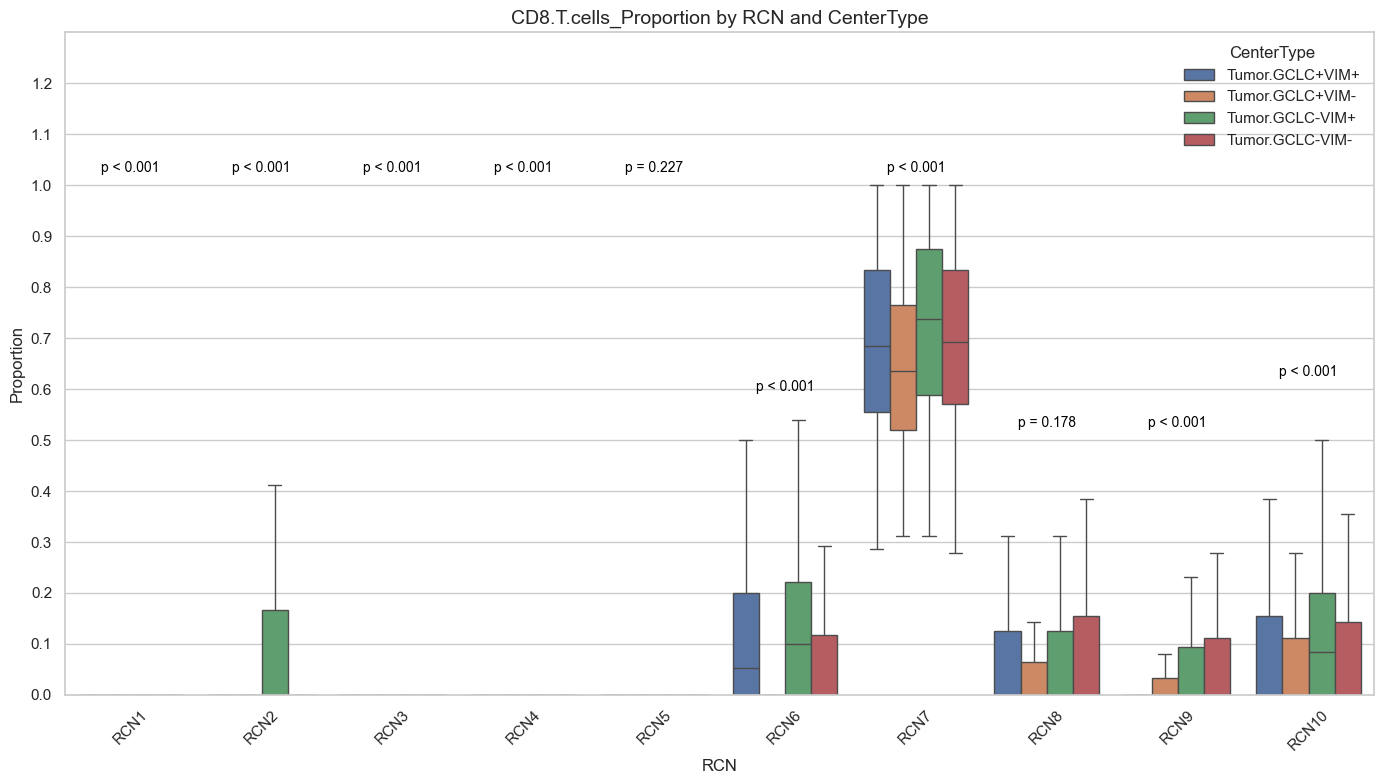

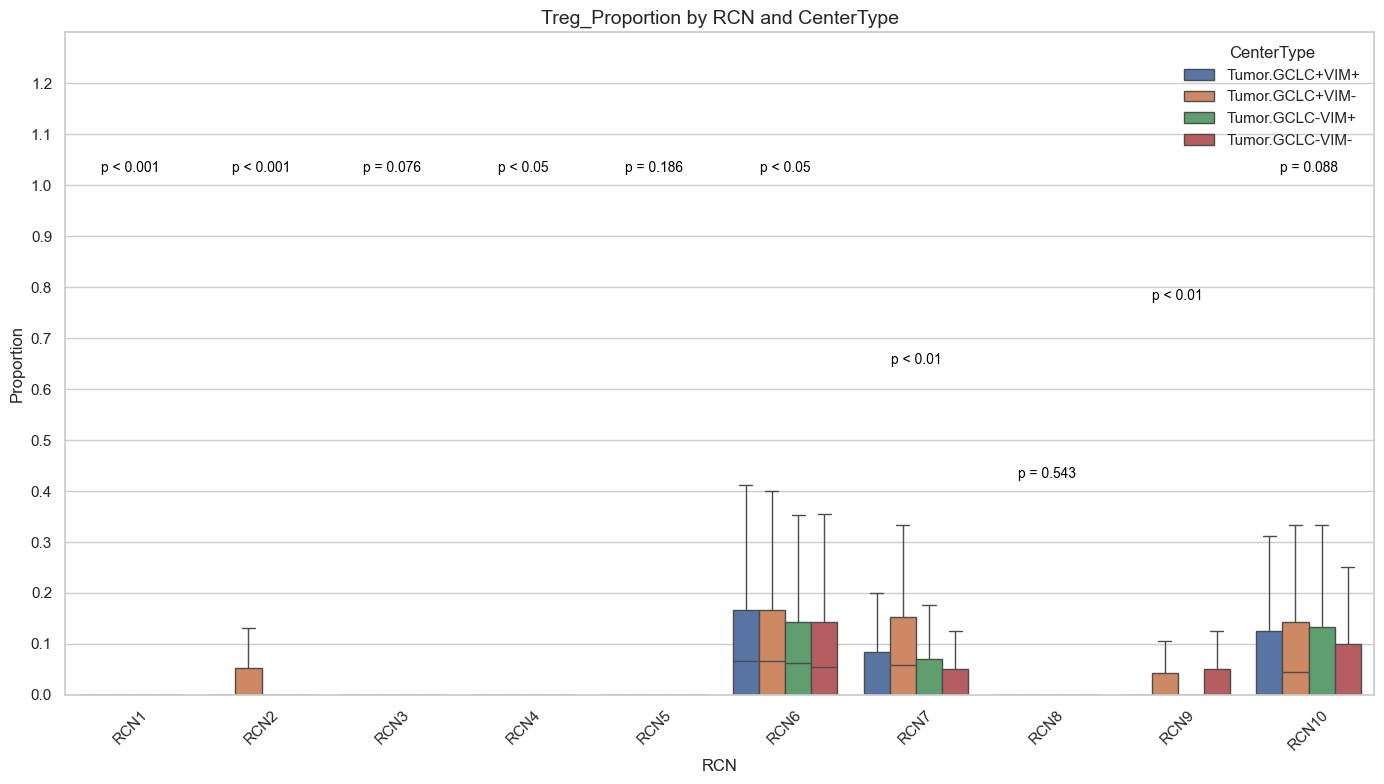

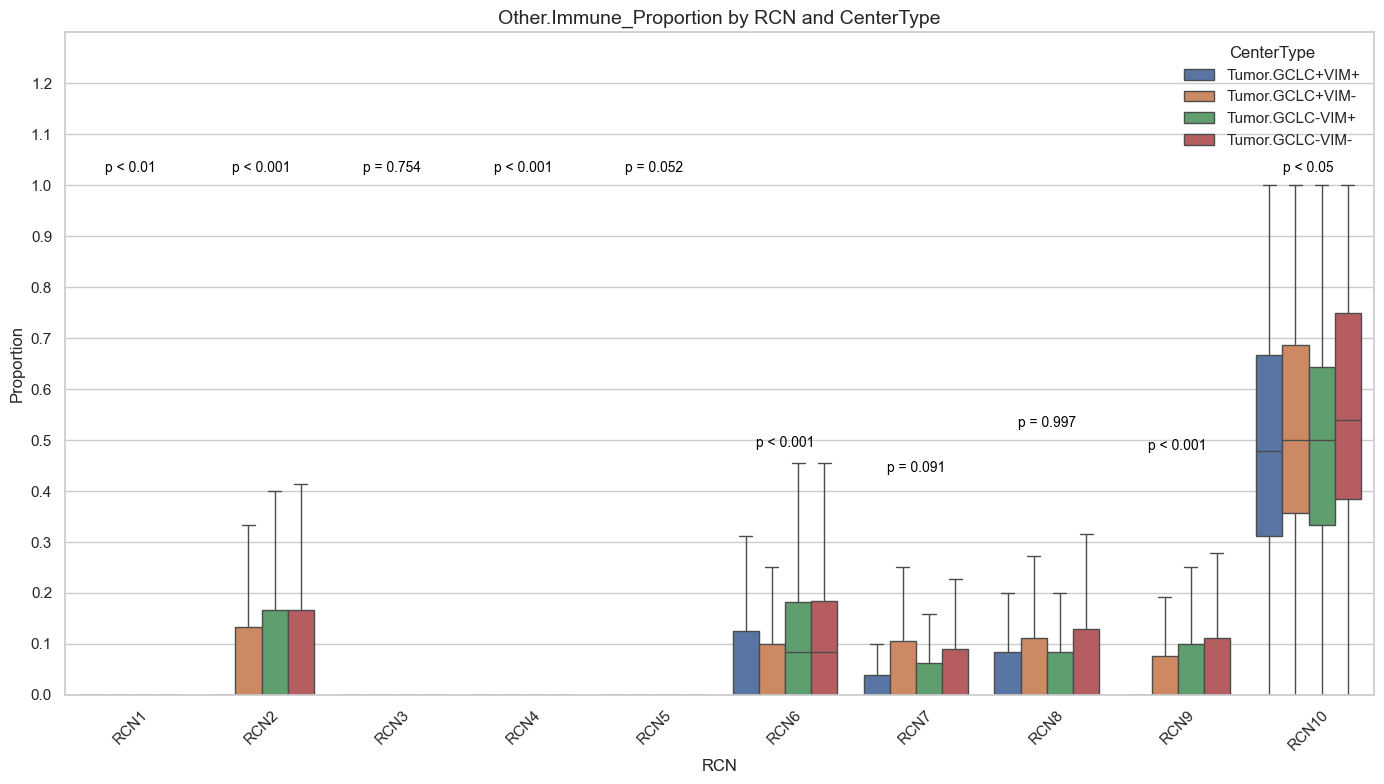

In [129]:
# Filter data to include only valid RCNs
df = cell_df

# Define center types for comparison
center_types = ["Tumor.GCLC+VIM+", "Tumor.GCLC-VIM+"]

# Create proper numeric ordering of RCNs
rcn_order = sorted(df['RCN'].unique(), key=lambda x: int(x.replace('RCN', '')))

# Loop through each immune cell type column
for col in immune_proportion_cols:
    
    global_y_min = df[col].min()
    global_y_max = df[col].max()
    global_y_range = global_y_max - global_y_min
    
    # Create figure with more space for annotations
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Create boxplot with ordered RCNs
    sns.boxplot(ax=ax, data=df, x="RCN", y=col, hue="CenterType", 
                showfliers=False, order=rcn_order)
    
    # Set plot title and labels
    ax.set_title(f"{col} by RCN and CenterType", fontsize=14)
    ax.set_xlabel("RCN", fontsize=12)
    ax.set_ylabel("Proportion", fontsize=12)
    plt.xticks(rotation=45)
    
    # Add extra space on top for annotations
    ax.set_ylim(global_y_min, global_y_max + global_y_range * 0.3)
    ax.set_yticks(np.arange(global_y_min, global_y_max + global_y_range * 0.3, step=0.1))
    
    # For each RCN, perform statistical test
    for idx, rcn in enumerate(rcn_order):
        # Filter data for current RCN
        sub_df = df[df["RCN"] == rcn]
        
        # Get data for each center type
        data_group = {}
        for ct in center_types:
            data_tmp = sub_df[sub_df["CenterType"] == ct][col].dropna()
            if len(data_tmp) < 2:
                continue
            data_group[ct] = data_tmp.values
        
        # Only perform test if we have data for both groups
        if len(data_group) == 2:
            try:
                stat, p_value = mannwhitneyu(data_group[center_types[0]], data_group[center_types[1]])
                
                # Calculate maximum value from both groups
                group_values = np.concatenate([data_group[center_types[0]], data_group[center_types[1]]])
                local_max = np.max(group_values)
                
                # Calculate y-position for annotation
                y_offset = y_range * 0.05
                y_pos = local_max + y_offset
                
                # Format p-value text
                if p_value < 0.001:
                    p_text = "p < 0.001"
                elif p_value < 0.01:
                    p_text = "p < 0.01"
                elif p_value < 0.05:
                    p_text = "p < 0.05"
                else:
                    p_text = f"p = {p_value:.3f}"
                
                # Add annotation
                ax.text(idx, y_pos, p_text, 
                        horizontalalignment='center', color='black', fontsize=10)
                        
            except ValueError:
                # Skip if test fails
                continue
    
    plt.legend(title="CenterType", loc="upper right")
    plt.tight_layout()
    plt.show()


In [109]:
result_df

,CenterType,RCN,ImmuneCellType,MeanProportion,NormalizedProportion
0,Tumor.GCLC+VIM+,RCN1,CD206.Macrophages,0.699731,0.170177
1,Tumor.GCLC+VIM+,RCN1,CD4.T.cells,0.640644,0.155807
2,Tumor.GCLC+VIM+,RCN1,CD68.Macrophages,0.846041,0.205760
3,Tumor.GCLC+VIM+,RCN1,CD8.T.cells,0.648038,0.157605
4,Tumor.GCLC+VIM+,RCN1,Other.Immune,0.639011,0.155410
...,...,...,...,...,...
235,Tumor.GCLC-VIM-,RCN9,CD4.T.cells,0.133863,0.089729
236,Tumor.GCLC-VIM-,RCN9,CD68.Macrophages,0.757420,0.507704
237,Tumor.GCLC-VIM-,RCN9,CD8.T.cells,0.194575,0.130425
238,Tumor.GCLC-VIM-,RCN9,Other.Immune,0.157276,0.105423


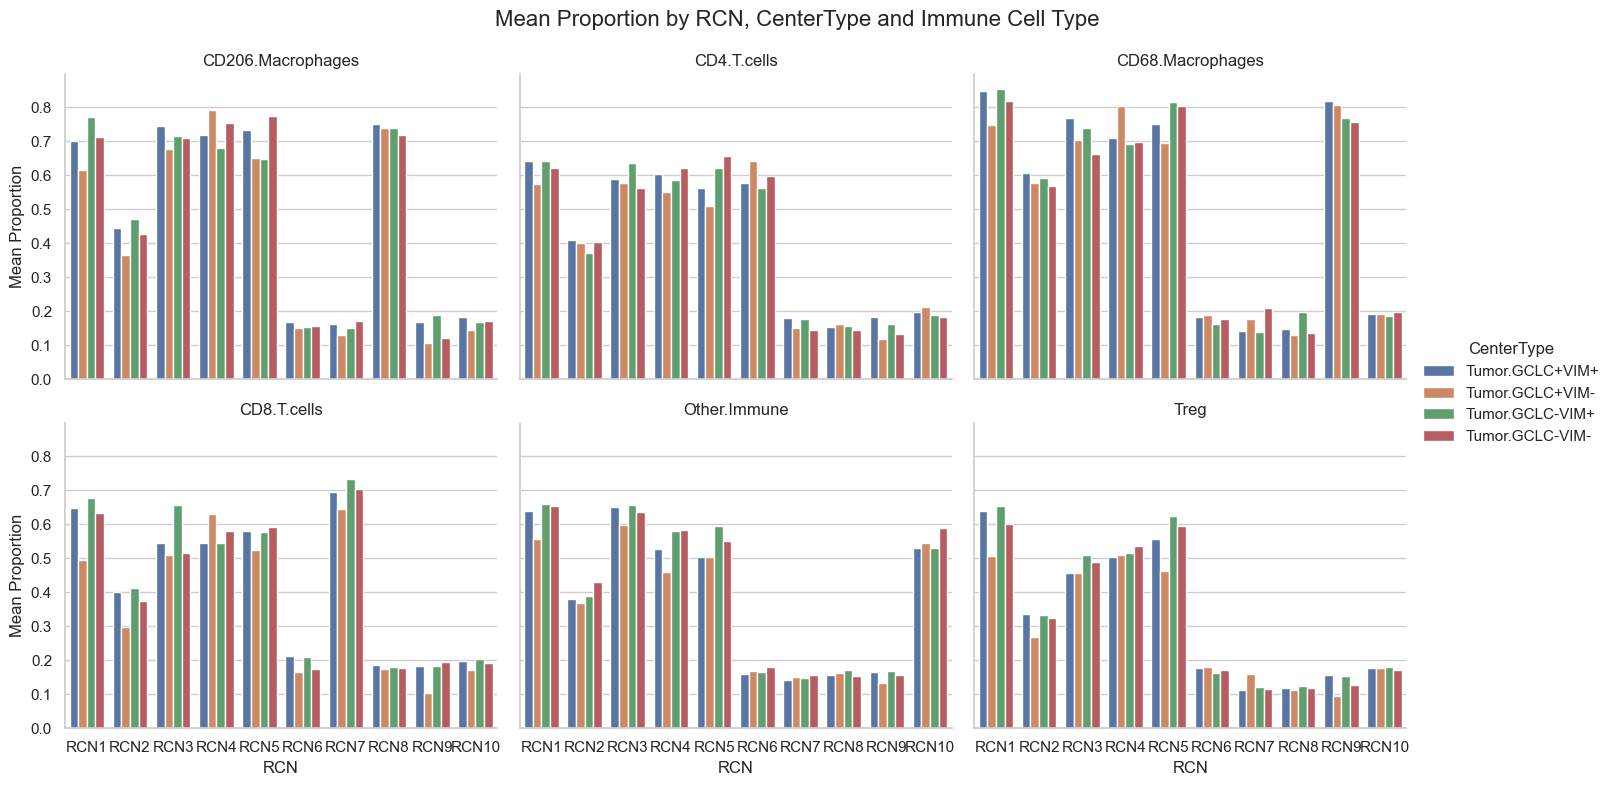

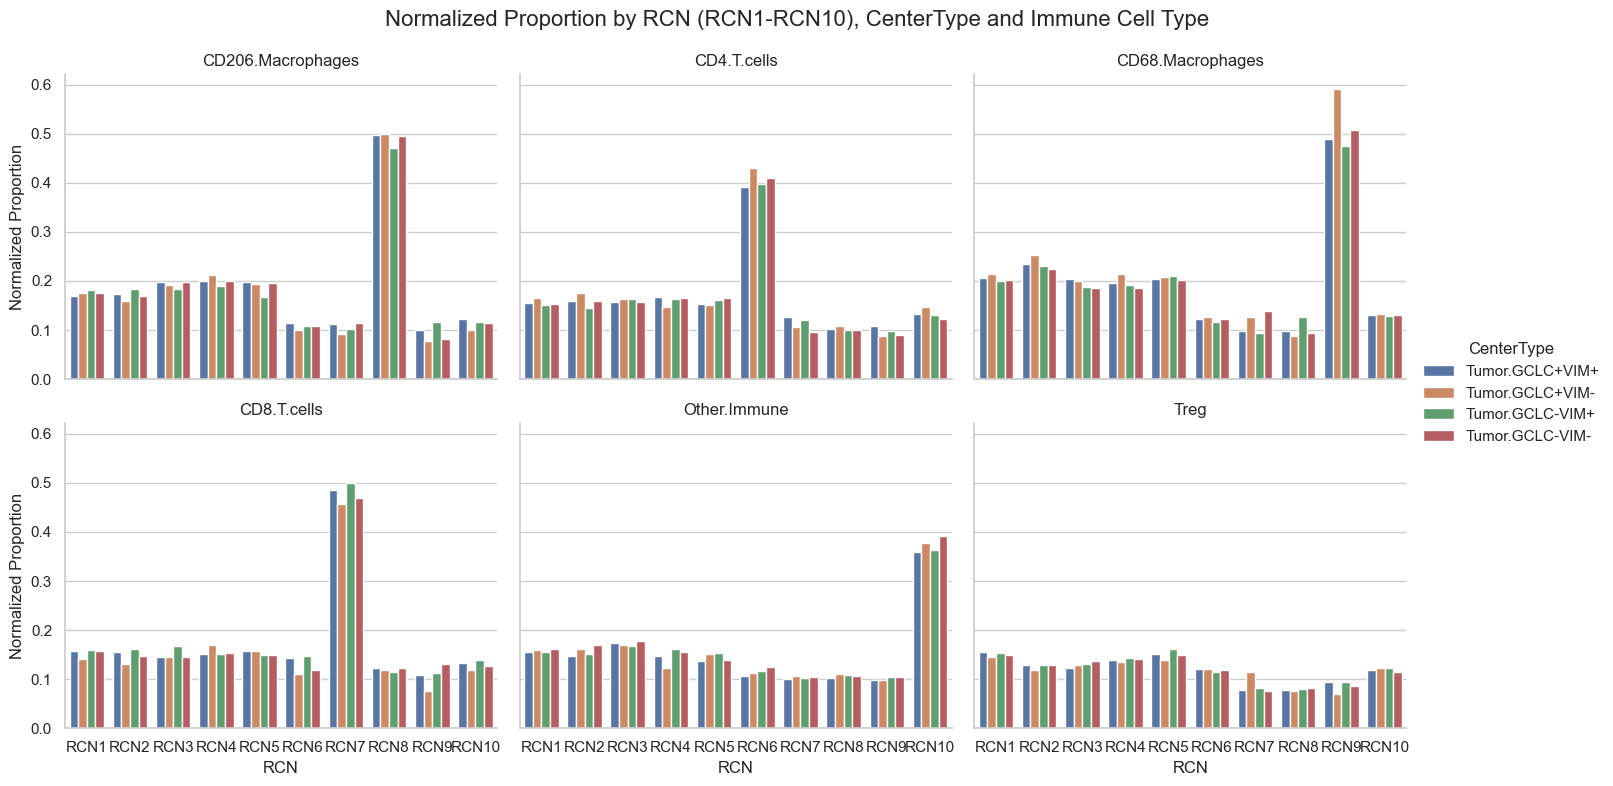

In [114]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 读取数据，假设数据保存在 "data_aggregated.tsv" 文件中，分隔符为制表符
df = result_df

# 只保留 RCN1 至 RCN10 的样本，并指定按顺序排列的列表
valid_rcn = [f"RCN{i}" for i in range(1, 11)]
df = df[df["RCN"].isin(valid_rcn)]

# 设置绘图风格
sns.set(style="whitegrid")

# 指定 x 轴类别的顺序，确保按照 RCN1-RCN10 顺序排列
order_rcn = valid_rcn

# 绘制 MeanProportion 图：按 ImmuneCellType 分面，每个子图中横坐标为 RCN，颜色区分 CenterType
g_mean = sns.catplot(
    data=df,
    kind="bar",
    x="RCN",
    y="MeanProportion",
    hue="CenterType",
    col="ImmuneCellType",   # 按免疫细胞类型分面
    col_wrap=3,             # 每行3个子图
    height=4,
    aspect=1.2,
    order=order_rcn         # 指定 x 轴顺序
)

g_mean.set_titles("{col_name}")
g_mean.set_axis_labels("RCN", "Mean Proportion")
g_mean.fig.subplots_adjust(top=0.9)
g_mean.fig.suptitle("Mean Proportion by RCN, CenterType and Immune Cell Type", fontsize=16)

plt.show()

# 绘制 NormalizedProportion 图：绘图方式同上，使用相同的顺序参数 order
g_norm = sns.catplot(
    data=df,
    kind="bar",
    x="RCN",
    y="NormalizedProportion",
    hue="CenterType",
    col="ImmuneCellType",
    col_wrap=3,
    height=4,
    aspect=1.2,
    order=order_rcn         # 指定 x 轴顺序
)

g_norm.set_titles("{col_name}")
g_norm.set_axis_labels("RCN", "Normalized Proportion")
g_norm.fig.subplots_adjust(top=0.9)
g_norm.fig.suptitle("Normalized Proportion by RCN (RCN1-RCN10), CenterType and Immune Cell Type", fontsize=16)

plt.show()
